In [10]:
import os
import pandas as pd
from collections import defaultdict

def collect_sound_files(root_dir):
    instruments = ['Wavetable', 'Analog', 'Operator']
    sound_files = defaultdict(lambda: defaultdict(list))
    
    for instrument in instruments:
        instrument_path = os.path.join(root_dir, instrument)
        if os.path.exists(instrument_path):
            for sound_type in os.listdir(instrument_path):
                sound_type_path = os.path.join(instrument_path, sound_type)
                if os.path.isdir(sound_type_path):
                    for file in os.listdir(sound_type_path):
                        if file.endswith('.adv') or file.endswith('.adg'):
                            sound_files[instrument][sound_type].append(file)
    
    return sound_files

def generate_dataframe(sound_files):
    data = []
    id_counters = {'Wavetable': 1, 'Analog': 1, 'Operator': 1}
    id_prefixes = {'Wavetable': 'wt', 'Analog': 'an', 'Operator': 'op'}
    
    for instrument, sound_types in sound_files.items():
        for sound_type in sorted(sound_types.keys()):
            for file in sorted(sound_types[sound_type]):
                preset_id = f"{id_prefixes[instrument]}{id_counters[instrument]:03d}"
                data.append({
                    'id': preset_id,
                    'name': file,
                    'instrument': instrument,
                    'category': sound_type  # Add the sound type as 'category'
                })
                id_counters[instrument] += 1
    
    return pd.DataFrame(data)

In [3]:
# Usage
root_dir = '/Users/jake/Source/muse-art/polyhymnia/data/presets/Ableton Synth Presets'
sound_files = collect_sound_files(root_dir)
df = generate_dataframe(sound_files)
print(df)

        id                         name instrument            category
0    wt001        Descenting Dreams.adv  Wavetable  Ambient & Evolving
1    wt002     Drifting Ambient Pad.adv  Wavetable  Ambient & Evolving
2    wt003           Echoic Chamber.adv  Wavetable  Ambient & Evolving
3    wt004  Embellish The Dead Zone.adv  Wavetable  Ambient & Evolving
4    wt005           Flux Capacitor.adv  Wavetable  Ambient & Evolving
..     ...                          ...        ...                 ...
652  op327               Flute Hard.adv   Operator               Winds
653  op328             Flute Mellow.adv   Operator               Winds
654  op329            Ocarina Basic.adv   Operator               Winds
655  op330          Pan Flute Basic.adv   Operator               Winds
656  op331           Whistler Winds.adv   Operator               Winds

[657 rows x 4 columns]


In [13]:
# Usage
root_dir = '/Users/jake/Source/muse-art/polyhymnia/data/presets/Live 12 Instruments/Instruments/'
sound_files = collect_sound_files(root_dir)
df = generate_dataframe(sound_files)
print(df)

        id                         name instrument            category
0    wt001        Descenting Dreams.adv  Wavetable  Ambient & Evolving
1    wt002     Drifting Ambient Pad.adv  Wavetable  Ambient & Evolving
2    wt003           Echoic Chamber.adv  Wavetable  Ambient & Evolving
3    wt004  Embellish The Dead Zone.adv  Wavetable  Ambient & Evolving
4    wt005           Flux Capacitor.adv  Wavetable  Ambient & Evolving
..     ...                          ...        ...                 ...
654  op327               Flute Hard.adv   Operator               Winds
655  op328             Flute Mellow.adv   Operator               Winds
656  op329            Ocarina Basic.adv   Operator               Winds
657  op330          Pan Flute Basic.adv   Operator               Winds
658  op331           Whistler Winds.adv   Operator               Winds

[659 rows x 4 columns]


In [7]:
df.to_csv('./ableton_synth_preset_list.csv', index=False)

<Axes: xlabel='category'>

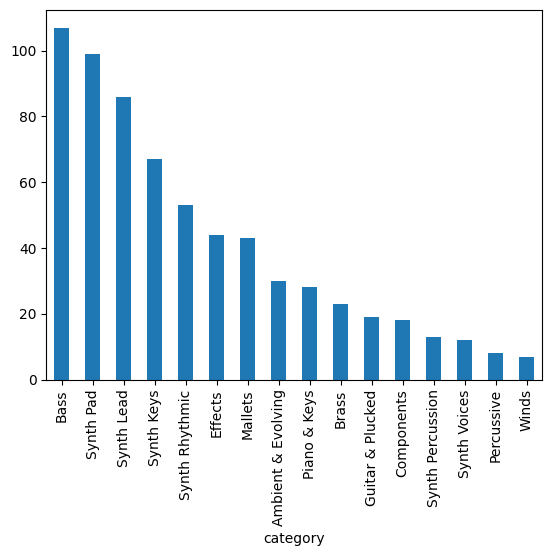

In [4]:
df['category'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

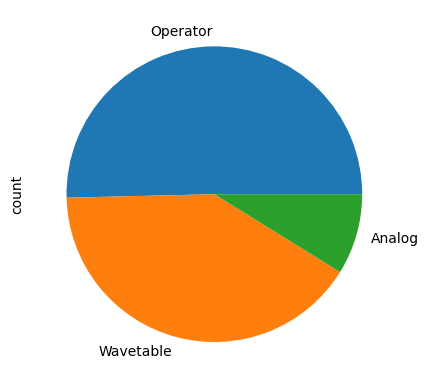

In [6]:
df['instrument'].value_counts().plot(kind='pie')

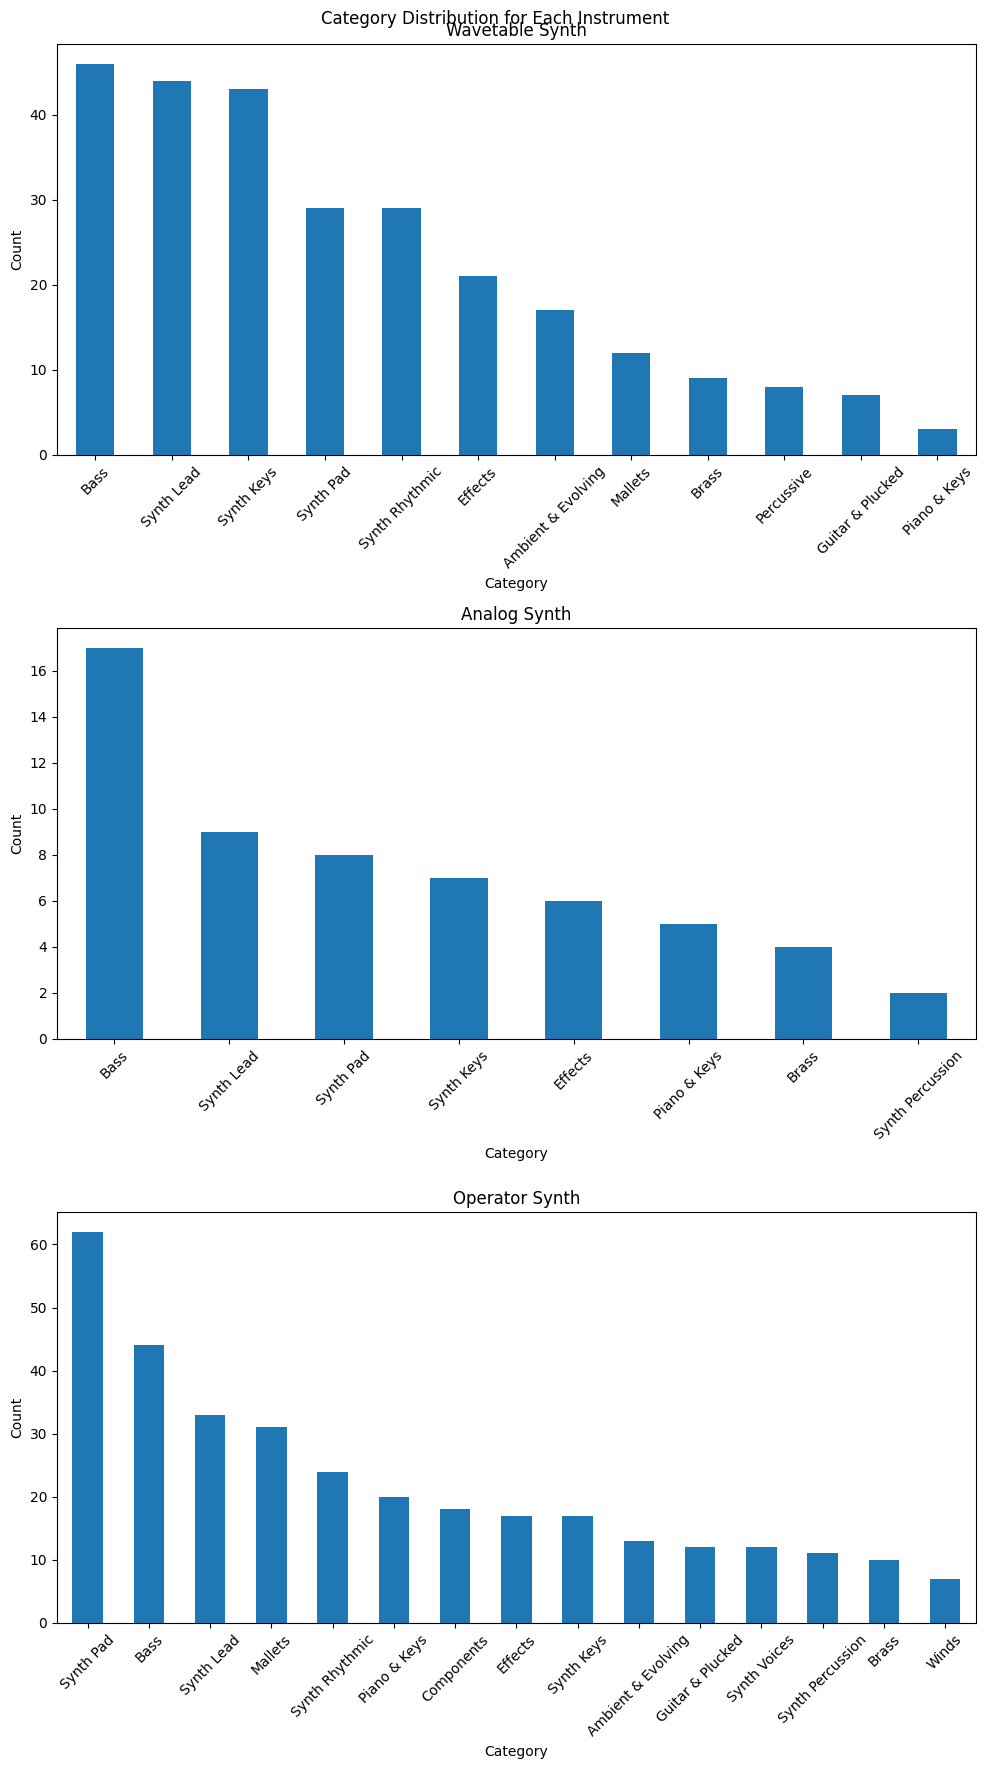

In [9]:
from matplotlib import pyplot as plt

instruments = ['Wavetable', 'Analog', 'Operator']

fig, axes = plt.subplots(3, 1, figsize=(10, 18))
fig.suptitle('Category Distribution for Each Instrument')

for i, instrument in enumerate(instruments):
    # Filter the dataframe for the current instrument
    instrument_df = df[df['instrument'] == instrument]
    
    # Plot category counts for the current instrument
    instrument_df['category'].value_counts().plot(kind='bar', ax=axes[i])
    
    # Set title and labels for each subplot
    axes[i].set_title(f'{instrument} Synth')
    axes[i].set_xlabel('Category')
    axes[i].set_ylabel('Count')
    
    # Rotate x-axis labels for better readability
    axes[i].tick_params(axis='x', rotation=45)

# Adjust layout to prevent overlapping
plt.tight_layout()

# Display the plot
plt.show()


In [2]:
import gzip
import xml.etree.ElementTree as ET
import sys

def read_adv_file(file_path):
    #try:
        # Open and decompress the gzipped file
        with gzip.open(file_path, 'rb') as f:
            xml_content = f.read()
        
        # Parse the XML content
        root = ET.fromstring(xml_content)

        
        '''# Print the XML structure
        print(ET.tostring(root, encoding='unicode', method='xml'))
    except gzip.BadGzipFile:
        print(f"Error: {file_path} is not a valid gzip file.")
    except ET.ParseError:
        print(f"Error: Unable to parse XML content in {file_path}.")
    except FileNotFoundError:
        print(f"Error: File {file_path} not found.")
    except Exception as e:
        print(f"An unexpected error occurred: {str(e)}")'''

        return root

# Usag

In [19]:
filepath = '/Users/jake/Source/muse-art/polyhymnia/data/presets/Ableton Synth Presets/Racks/Instrument Racks/Mallets/Ambient Computer Bell.adg'
read_adv_file(filepath)

<Element 'Ableton' at 0x129f97970>

In [7]:
import xml.etree.ElementTree as ET
import os

def parse_adg_file(root):
    
    # Find the FileRef element
    file_ref = root.find(".//FileRef")
    if file_ref is not None:
        relative_path = file_ref.find("RelativePath").get("Value")
        filename = os.path.basename(relative_path)
    else:
        filename = "Unknown"

    # Define a mapping of XML tags to instrument names
    instrument_mapping = {
        "InstrumentVector": "Wavetable",
        "InstrumentImpulse": "Impulse",
        "OriginalSimpler": "Simpler",
        "UltraAnalog": "Analog",
        "Operator": "Operator",
        "StringStudio": "Tension",
        "LoungeLizard": "Electric",
        "Collision": "Collision",
    }

    # Find the instrument type
    instrument_type = "Unknown"
    device_elements = root.findall(".//Device/*")
    for device in device_elements:
        if device.tag in instrument_mapping:
            instrument_type = instrument_mapping[device.tag]
            break
        elif device.tag == "InstrumentGroupDevice":
            # For InstrumentGroupDevice, we need to look deeper
            for nested_device in device.findall(".//Device/*"):
                if nested_device.tag in instrument_mapping:
                    instrument_type = instrument_mapping[nested_device.tag]
                    break
            if instrument_type != "Unknown":
                break

    return {filename: instrument_type}

def process_directory(directory):
    results = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.endswith('.adg'):
                file_path = os.path.join(root, file)
                try:
                    xml_content = read_adv_file(file_path)
                    result = parse_adg_file(xml_content)
                    results.append(result)
                except Exception as e:
                    print(f"Error processing file {file_path}: {str(e)}")
    return results

# Process all .adg files in the specified directory and its subdirectories
#directory = '/Users/jake/Source/muse-art/polyhymnia/data/presets/Ableton Synth Presets/Racks/Instrument Racks/'
directory = '/Users/jake/Source/muse-art/polyhymnia/data/presets/Live 12 Instruments/Instrument Racks/'
instrument_list = process_directory(directory)

# Print the results
for item in instrument_list:
    print(item)


{'Synthetic Strings.adg': 'Wavetable'}
{'': 'Wavetable'}
{'Evangelis Strings.adg': 'Unknown'}
{'Razor Strings.adg': 'Unknown'}
{'Off World Strings.adg': 'Analog'}
{'M Tron Strings.adg': 'Analog'}
{'Synthetic Choir Strings.adg': 'Analog'}
{'Strings Pizz Basic.adg': 'Simpler'}
{'Strings Pizz Oct.adg': 'Simpler'}
{'Second Stellar Strings.adg': 'Wavetable'}
{'Strings Pizz Stage.adg': 'Simpler'}
{'Cruiser Strings.adg': 'Wavetable'}
{'Feedback Bow.adg': 'Tension'}
{'Magnetic Strings.adg': 'Wavetable'}
{'MPE Synth Bow.adg': 'Wavetable'}
{'Warping Strings.adg': 'Tension'}
{'MPE Cello Bow.adg': 'Tension'}
{'Cloud Cover Arp.adg': 'Wavetable'}
{'Rhythmic Oshima Pluck.adg': 'Collision'}
{'Mikado.adg': 'Wavetable'}
{'Mean Pulse.adg': 'Wavetable'}
{'Pulsing Click Pad.adg': 'Wavetable'}
{'Mouse Arp.adg': 'Unknown'}
{'Uplift Strings Arp.adg': 'Analog'}
{'Instrument Rack': 'Unknown'}
{'Live Wire.adg': 'Wavetable'}
{'Sencha Arp.adg': 'Analog'}
{'Chord Molecule Pulse.adg': 'Wavetable'}
{'Daily Routine RR

In [8]:
# Count the occurrences of each instrument type
from collections import Counter

instrument_counts = Counter()
for item in instrument_list:
    instrument_counts.update(item.values())

# Print the count for each category
for instrument, count in instrument_counts.items():
    print(f"{instrument}: {count}")

# Total number of instruments
print(f"\nTotal number of instruments: {len(instrument_list)}")

Wavetable: 381
Unknown: 122
Analog: 19
Simpler: 41
Tension: 20
Collision: 13
Operator: 55
Electric: 8

Total number of instruments: 659


In [21]:
# Count the occurrences of each instrument type
from collections import Counter

instrument_counts = Counter()
for item in instrument_list:
    instrument_counts.update(item.values())

# Print the count for each category
for instrument, count in instrument_counts.items():
    print(f"{instrument}: {count}")

# Total number of instruments
print(f"\nTotal number of instruments: {len(instrument_list)}")

Wavetable: 160
Analog: 18
Tension: 14
Collision: 10
Operator: 53
Unknown: 4
Simpler: 7
Electric: 8

Total number of instruments: 274


In [23]:
unknown_instruments = [item for item in instrument_list if list(item.values())[0] == 'Unknown']
print(f"Number of unknown instruments: {len(unknown_instruments)}")
print("First 5 unknown instruments:")
for item in unknown_instruments[:5]:
    print(item)

Number of unknown instruments: 4
First 5 unknown instruments:
{'MPE FM Arp.adg': 'Unknown'}
{'MPE Dulcimatica.adg': 'Unknown'}
{'MPE Inside Angel.adg': 'Unknown'}
{'MPE Sci-Fi Flicks.adg': 'Unknown'}


In [69]:
import xml.etree.ElementTree as ET
import os

def parse_adg_file(root, file_path):
    # Find the FileRef element
    file_ref = root.find(".//FileRef")
    if file_ref is not None:
        relative_path = file_ref.find("RelativePath").get("Value")
        filename = os.path.basename(relative_path)
    else:
        filename = os.path.basename(file_path)

    # Define a mapping of XML tags to instrument names
    instrument_mapping = {
        "InstrumentVector": "Wavetable",
        "InstrumentImpulse": "Impulse",
        "OriginalSimpler": "Simpler",
        "UltraAnalog": "Analog",
        "Operator": "Operator",
        "StringStudio": "Tension",
        "LoungeLizard": "Electric"
    }

    # Find the instrument type
    instrument_type = "Unknown"
    device_elements = root.findall(".//Device/*")
    for device in device_elements:
        if device.tag in instrument_mapping:
            instrument_type = instrument_mapping[device.tag]
            break
        elif device.tag == "InstrumentGroupDevice":
            # For InstrumentGroupDevice, we need to look deeper
            for nested_device in device.findall(".//Device/*"):
                if nested_device.tag in instrument_mapping:
                    instrument_type = instrument_mapping[nested_device.tag]
                    break
            if instrument_type != "Unknown":
                break
    print(f"File: {os.path.basename(file_path)}, Instrument Type: {instrument_type}")

    return filename, instrument_type, file_path

def process_directory(directory):
    results = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.endswith('.adg'):
                file_path = os.path.join(root, file)
                try:
                    xml_content = read_adv_file(file_path)
                    filename, instrument_type, full_path = parse_adg_file(xml_content, file_path)
                    relative_path = os.path.relpath(full_path, directory)
                    parts = relative_path.split(os.sep)
                    category = parts[0] if len(parts) > 1 else "Uncategorized"
                    results.append({
                        "filename": filename,
                        "instrument_type": instrument_type,
                        "category": category
                    })
                except Exception as e:
                    print(f"Error processing file {file_path}: {str(e)}")
    return results

# Process all .adg files in the specified directory and its subdirectories
directory = '/Users/jake/Source/muse-art/polyhymnia/data/presets/Ableton Synth Presets/Racks/Instrument Racks/'
instrument_list = process_directory(directory)

# Filter for Wavetable instruments and sort alphabetically
wavetable_racks = sorted(
    [item for item in instrument_list if item['instrument_type'] == "Wavetable"],
    key=lambda x: x['filename']
)

# Create IDs for each Wavetable rack
wavetable_racks_with_ids = []
for i, rack in enumerate(wavetable_racks, start=1):
    wavetable_id = f"wtr{i:03d}"  # Creates IDs like wtr001, wtr002, etc.
    wavetable_racks_with_ids.append({
        "id": wavetable_id,
        "filename": rack['filename'],
        "category": rack['category']
    })

# Print the results
for item in wavetable_racks_with_ids:
    print(f"ID: {item['id']}, Category: {item['category']}, Filename: {item['filename']}")

print(f"\nTotal number of Wavetable instrument racks: {len(wavetable_racks_with_ids)}")

# Optionally, you can save the results to a file
# import json
# with open('wavetable_racks_with_ids_and_categories.json', 'w') as f:
#     json.dump(wavetable_racks_with_ids, f, indent=2)

File: Synthetic Strings.adg, Instrument Type: Wavetable
File: Off World Strings.adg, Instrument Type: Analog
File: M Tron Strings.adg, Instrument Type: Analog
File: Synthetic Choir Strings.adg, Instrument Type: Analog
File: Second Stellar Strings.adg, Instrument Type: Wavetable
File: Cruiser Strings.adg, Instrument Type: Wavetable
File: Feedback Bow.adg, Instrument Type: Tension
File: Magnetic Strings.adg, Instrument Type: Wavetable
File: Cloud Cover Arp.adg, Instrument Type: Wavetable
File: Rhythmic Oshima Pluck.adg, Instrument Type: Unknown
File: Pulsing Click Pad.adg, Instrument Type: Wavetable
File: Uplift Strings Arp.adg, Instrument Type: Analog
File: Sencha Arp.adg, Instrument Type: Analog
File: Chord Molecule Pulse.adg, Instrument Type: Wavetable
File: Rolling Hi Tech Perc.adg, Instrument Type: Unknown
File: Pulsing Raum Keys.adg, Instrument Type: Wavetable
File: Basic Harp Arp.adg, Instrument Type: Wavetable
File: Neptune Arp.adg, Instrument Type: Operator
File: Basic Pluck Arp

In [70]:
ana_racks = [item for item in instrument_list if item['instrument_type'] == 'Analog']
sorted_ana_racks = sorted(ana_racks, key=lambda x: x['filename'])
analog_racks = sorted_ana_racks

In [71]:
analog_racks

[{'filename': 'Badass Lead.adg',
  'instrument_type': 'Analog',
  'category': 'Synth Lead'},
 {'filename': 'Basic Analog Bass.adg',
  'instrument_type': 'Analog',
  'category': 'Bass'},
 {'filename': 'Basic Saturated Bass.adg',
  'instrument_type': 'Analog',
  'category': 'Bass'},
 {'filename': 'Basic Saturated Bass.adg',
  'instrument_type': 'Analog',
  'category': 'Bass'},
 {'filename': 'Basic Silk Horns.adg',
  'instrument_type': 'Analog',
  'category': 'Brass'},
 {'filename': 'Canadian Keys.adg',
  'instrument_type': 'Analog',
  'category': 'Synth Keys'},
 {'filename': 'Chord Analog Brass-1.adg',
  'instrument_type': 'Analog',
  'category': 'Brass'},
 {'filename': 'Complex Rotor Lead.adg',
  'instrument_type': 'Analog',
  'category': 'Synth Lead'},
 {'filename': 'Fat Leather Bass.adg',
  'instrument_type': 'Analog',
  'category': 'Bass'},
 {'filename': 'Fuzzy Analog Keys.adg',
  'instrument_type': 'Analog',
  'category': 'Synth Keys'},
 {'filename': 'M Tron Strings.adg',
  'instrum

In [73]:
'''# Filter for analog instruments and sort alphabetically
analog_racks = sorted(
    [item for item in instrument_list if item['instrument_type'] == "analog"],
    key=lambda x: x['filename']
)'''

# Create IDs for each analog rack
analog_racks_with_ids = []
for i, rack in enumerate(analog_racks, start=1):
    analog_id = f"anr{i:03d}"  # Creates IDs like wtr001, wtr002, etc.
    analog_racks_with_ids.append({
        "id": analog_id,
        "filename": rack['filename'],
        "category": rack['category']
    })

# Print the results
for item in analog_racks_with_ids:
    print(f"ID: {item['id']}, Category: {item['category']}, Filename: {item['filename']}")

print(f"\nTotal number of analog instrument racks: {len(analog_racks_with_ids)}")

# Optionally, you can save the results to a file
# import json
# with open('analog_racks_with_ids_and_categories.json', 'w') as f:
#     json.dump(analog_racks_with_ids, f, indent=2)

ID: anr001, Category: Synth Lead, Filename: Badass Lead.adg
ID: anr002, Category: Bass, Filename: Basic Analog Bass.adg
ID: anr003, Category: Bass, Filename: Basic Saturated Bass.adg
ID: anr004, Category: Bass, Filename: Basic Saturated Bass.adg
ID: anr005, Category: Brass, Filename: Basic Silk Horns.adg
ID: anr006, Category: Synth Keys, Filename: Canadian Keys.adg
ID: anr007, Category: Brass, Filename: Chord Analog Brass-1.adg
ID: anr008, Category: Synth Lead, Filename: Complex Rotor Lead.adg
ID: anr009, Category: Bass, Filename: Fat Leather Bass.adg
ID: anr010, Category: Synth Keys, Filename: Fuzzy Analog Keys.adg
ID: anr011, Category: Strings, Filename: M Tron Strings.adg
ID: anr012, Category: Strings, Filename: Off World Strings.adg
ID: anr013, Category: Brass, Filename: Poly Synth Brass.adg
ID: anr014, Category: Synth Rhythmic, Filename: Sencha Arp.adg
ID: anr015, Category: Strings, Filename: Spacious Synth Choir.adg
ID: anr016, Category: Bass, Filename: Thermal Runway Bass.adg
ID

In [34]:
import pandas as pd

df = pd.read_csv('./ableton_synth_preset_list.csv')

In [35]:
len(df)

657

In [74]:
import pandas as pd

# Convert wavetable_racks_with_ids to a dataframe
new_df = pd.DataFrame(analog_racks_with_ids)

# Rename columns to match the existing dataframe
new_df = new_df.rename(columns={'filename': 'name'})

# Add the 'instrument' column with value 'Wavetable' for all rows
new_df['instrument'] = 'Analog'

# Ensure the column order matches the existing dataframe
new_df = new_df[['id', 'name', 'instrument', 'category']]

In [75]:
new_df.to_csv('analog_racks_with_ids.csv', index=False)

In [65]:
import pandas as pd

# Convert wavetable_racks_with_ids to a dataframe
new_df = pd.DataFrame(analog_racks_with_ids)

# Rename columns to match the existing dataframe
new_df = new_df.rename(columns={'filename': 'name'})

# Add the 'instrument' column with value 'Wavetable' for all rows
new_df['instrument'] = 'Analog'

# Ensure the column order matches the existing dataframe
new_df = new_df[['id', 'name', 'instrument', 'category']]

# Append the new data to the existing dataframe
combined_df = pd.concat([df, new_df], ignore_index=True)

# Sort by the id
combined_df = combined_df.sort_values('id')

# Reset the index
combined_df = combined_df.reset_index(drop=True)

# Display the first few rows of the updated dataframe
print(combined_df.head())

# Display the last few rows to see the newly added data
print("\nLast few rows (newly added data):")
print(combined_df.tail())

# Print the total number of rows in the combined dataframe
print(f"\nTotal number of rows: {len(combined_df)}")

# Optionally, save the updated dataframe
# combined_df.to_csv('updated_wavetable_racks.csv', index=False)

      id                             name instrument category
0  an001   Dual OSC Buzz Octaves Bass.adv     Analog     Bass
1  an002        Dual OSC Plastic Bass.adv     Analog     Bass
2  an003     Dual OSC Reso Noise Bass.adv     Analog     Bass
3  an004         Dual OSC Rubber Bass.adv     Analog     Bass
4  an005  Dual OSC Sample & Hold Bass.adv     Analog     Bass

Last few rows (newly added data):
         id                 name instrument  category
812  wtr156   Vaporesque Pad.adg  Wavetable       Pad
813  wtr157    Voicelike Pad.adg  Wavetable       Pad
814  wtr158      Water Pluck.adg  Wavetable   Plucked
815  wtr159  Wave Evolve Pad.adg  Wavetable  Evolving
816  wtr160      Wet Air Pad.adg  Wavetable       Pad

Total number of rows: 817


In [63]:
new_df

,id,name,instrument,category
0,opr001,Basic Brushed Bells.adg,Operator,Mallets
1,opr002,Basic FM Bells.adg,Operator,Mallets
2,opr003,Basic Fanatik Bass.adg,Operator,Bass
3,opr004,Basic Fine Line Bass.adg,Operator,Bass
4,opr005,Basic Mello Bass.adg,Operator,Bass
5,opr006,Basic Metallic Noise Pluck.adg,Operator,Plucked
6,opr007,Basic Particles Keys.adg,Operator,Synth Keys
7,opr008,Basic Pluck Keys.adg,Operator,Synth Keys
8,opr009,Basic Sine Drive Lead.adg,Operator,Synth Lead
9,opr010,Basic Sine Keys.adg,Operator,Synth Keys
